# GDGoC ML Study Jam — Chapter 2 Challenge
## **Topic: The Airline Experience Analyst** ✈️📊

Selamat datang, Data Detective! 🕵️‍♂️  
Di challenge ini kamu bukan cuma “bersihin data”, tapi **ngambil keputusan dari EDA** dan bikin data siap buat ML.


![GIF](https://media2.giphy.com/media/v1.Y2lkPTc5MGI3NjExOWVpdnRnd2ppNXlvYTQ2ZjAxNW1icGRjOTlscTQ0dmlkZXkzbmoyOCZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/JIX9t2j0ZTN9S/giphy.gif)



# MAKE A COPY DULU YA GUYS

## **Skenario**
Kamu adalah **Lead Data Analyst** di sebuah maskapai. Tim Customer Experience lagi panik karena rating kepuasan turun dan banyak komplain yang “katanya” random.

Bosmu ngasih dataset **Airline Passenger Satisfaction** dan minta kamu:
- menemukan pola kepuasan pelanggan,
- membuktikan faktor paling berpengaruh,
- dan menyiapkan dataset **ML-ready** untuk prediksi kepuasan bulan depan.

Dataset: Kaggle — **Airline Passenger Satisfaction** (`train.csv`)

## **Misi Utama**
Kamu harus menyelesaikan 3 hal:
1) **Preprocessing Tahap 1 (Cleaning):** bikin data rapi dan konsisten  
2) **EDA yang berdampak:** visualisasi harus menjawab pertanyaan, bukan ngasal  
3) **Preprocessing Tahap 2 (EDA-driven):** keputusanmu harus berdasarkan temuan EDA  

## **Aturan Main**
1. **Bebas Berkreasi:** boleh pakai pandas, matplotlib/seaborn, sklearn, pipeline, dll. (BOLEH PAKAI AI JUGA YA GUYS, CHATGPT OR ANYTHING)
2. **Wajib Ada Insight:** setiap bagian EDA harus menghasilkan kesimpulan singkat.  
3. **Wajib Ada Keputusan:** minimal **3 keputusan preprocessing tahap 2** dengan format:  
   **Temuan → Keputusan → Alasan**  
4. **Notebook Harus Run:** dari atas sampai bawah tanpa error.  
5. **Have Fun!** ✨

## **Checklist Submission (Wajib)**
✅ Minimal **6 visualisasi** (boleh lebih)  
✅ Minimal **3 insight utama**  
✅ Minimal **3 keputusan preprocessing tahap 2**  
✅ Kesimpulan akhir (5–8 baris)

## **Tips Biar Kerasa “Data Detective”**
- Setiap lihat grafik, tanyain: **“So what?”** → keputusan apa yang diambil?  
- Bedakan **invalid** vs **outlier valid**  
- Jangan cuma plot — tulis alasan kenapa plot itu dibuat

# Data & Library Importation

In [ ]:
!wget "https://raw.githubusercontent.com/Ditt-A/GDGoC-StudyJamML2/main/data/Challenge%232/train.csv"

--2026-02-19 14:48:58--  https://raw.githubusercontent.com/Ditt-A/GDGoC-StudyJamML2/main/data/Challenge%232/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12193089 (12M) [text/plain]
Saving to: ‘train.csv.1’

train.csv.1         100%[===================>]  11.63M  --.-KB/s    in 0.1s    

2026-02-19 14:48:58 (119 MB/s) - ‘train.csv.1’ saved [12193089/12193089]



In [ ]:
#import data dan librarynya
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Data Overview

In [ ]:
#import data
df = pd.read_csv("train.csv")

In [ ]:
#info isi datanya
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [ ]:
#jumlah datanya
df.shape

(103904, 25)

In [ ]:
#Melihat 5 data teratas dan terbawah
df.head()
df.tail()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
103899,103899,94171,Female,disloyal Customer,23,Business travel,Eco,192,2,1,...,2,3,1,4,2,3,2,3,0.0,neutral or dissatisfied
103900,103900,73097,Male,Loyal Customer,49,Business travel,Business,2347,4,4,...,5,5,5,5,5,5,4,0,0.0,satisfied
103901,103901,68825,Male,disloyal Customer,30,Business travel,Business,1995,1,1,...,4,3,2,4,5,5,4,7,14.0,neutral or dissatisfied
103902,103902,54173,Female,disloyal Customer,22,Business travel,Eco,1000,1,1,...,1,4,5,1,5,4,1,0,0.0,neutral or dissatisfied
103903,103903,62567,Male,Loyal Customer,27,Business travel,Business,1723,1,3,...,1,1,1,4,4,3,1,0,0.0,neutral or dissatisfied


In [ ]:
#Statistik datanya
df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,51951.500000,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,29994.645522,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [ ]:
# jumlah missing value per fitur
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2) #pct = percentage
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).head(10)

#df.isna(): Mengecek setiap sel dalam DataFrame, mengembalikan True jika nilainya NaN/kosong, False jika tidak
#.sum(): Menjumlahkan jumlah True per kolom (karena True=1, False=0)
#.sort_values(ascending=False): Mengurutkan hasil dari terbanyak ke tersedikit (False = descending)

,missing_count,missing_pct
Arrival Delay in Minutes,310,0.3
id,0,0.0
Gender,0,0.0
Customer Type,0,0.0
Age,0,0.0
Type of Travel,0,0.0
Class,0,0.0
Flight Distance,0,0.0
Unnamed: 0,0,0.0
Inflight wifi service,0,0.0


# Data Cleaning

In [ ]:
#handling missing value numerikal menggunakan groupby
df_cpy_num1 = df.copy()
arrivalDelaymedian_by_age = df_cpy_num1.groupby('Age')['Arrival Delay in Minutes'].transform('median')
df_cpy_num1['Arrival Delay in Minutes'] = df_cpy_num1['Arrival Delay in Minutes'].fillna(arrivalDelaymedian_by_age)

df_cpy_num1[["Arrival Delay in Minutes"]].isna().sum()

,0
Arrival Delay in Minutes,0


In [ ]:
#handling missing value kategorikal menggunakan groupby
df_cpy_cat1 = df.copy()

df_cpy_cat1["Class"] = df_cpy_cat1["Class"].fillna(
    df_cpy_cat1.groupby("Age")["Class"].transform(lambda x: x.mode().iloc[0])
)

df_cpy_cat1["Gender"] = df_cpy_cat1["Gender"].fillna("Unknown")
df_cpy_cat1[["Class","Gender"]].isna().sum()

,0
Class,0
Gender,0


In [ ]:
#handling missing value numerikal menggunakan simple imputer
df_num = df.copy()

num_cols = ["Arrival Delay in Minutes", "Age", "Flight Distance", "Departure Delay in Minutes"]
print(df_num[num_cols].isna().sum())

Arrival Delay in Minutes      310
Age                             0
Flight Distance                 0
Departure Delay in Minutes      0
dtype: int64


In [ ]:
num_imputer = SimpleImputer(strategy="median")
df_num[num_cols] = num_imputer.fit_transform(df_num[num_cols])

df_num[num_cols].isna().sum()

,0
Arrival Delay in Minutes,0
Age,0
Flight Distance,0
Departure Delay in Minutes,0


In [ ]:
#handling missing value kategorikal menggunakan simpleimputer
df_cat = df.copy()

cat_cols = ["Class","Type of Travel", "Customer Type", "Gender"]
for c in cat_cols:
    print("\n", c)
    print(df_cat[c].value_counts(dropna=False).head(10))


 Class
Class
Business    49665
Eco         46745
Eco Plus     7494
Name: count, dtype: int64

 Type of Travel
Type of Travel
Business travel    71655
Personal Travel    32249
Name: count, dtype: int64

 Customer Type
Customer Type
Loyal Customer       84923
disloyal Customer    18981
Name: count, dtype: int64

 Gender
Gender
Female    52727
Male      51177
Name: count, dtype: int64


In [ ]:
mf_imputer = SimpleImputer(strategy="most_frequent")
df_cat[["Class", "Gender"]] = mf_imputer.fit_transform(df_cat[["Class", "Gender"]])

cabin_imputer = SimpleImputer(strategy="constant", fill_value="Unknown")
df_cat[["Customer Type"]] = cabin_imputer.fit_transform(df_cat[["Customer Type"]])

df_cat[cat_cols].isna().sum()

,0
Class,0
Type of Travel,0
Customer Type,0
Gender,0


In [ ]:
df[num_cols] = df_cpy_num1[num_cols]
df[cat_cols] = df_cpy_cat1[cat_cols]

In [ ]:
#handling duplicate value
print("Full-row duplicates:", df.duplicated().sum())
subset_key = ["Class","Type of Travel", "Customer Type"]
print("Duplicates by subset:", df.duplicated(subset=subset_key).sum())
df = df.drop_duplicates()
print("After drop_duplicates:", df.shape)

Full-row duplicates: 0
Duplicates by subset: 103892
After drop_duplicates: (103904, 25)


In [ ]:
#memperbaiki tipe-tipe data
print("Before:")
print(df.dtypes)

Before:
Unnamed: 0                             int64
id                                     int64
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
De

In [ ]:
to_num_cols = [
    "Age", "Flight Distance", "Inflight wifi service",
    "Departure/Arrival time convenient", "Ease of Online booking",
    "Gate location", "Food and drink", "Online boarding",
    "Seat comfort", "Inflight entertainment", "On-board service",
    "Leg room service", "Baggage handling", "Checkin service",
    "Inflight service", "Cleanliness",
    "Departure Delay in Minutes", "Arrival Delay in Minutes"
]

for col in to_num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [ ]:
cat_cols = ["Gender", "Customer Type", "Type of Travel", "Class", "satisfaction"]
df["Gender"] = df["Gender"].astype("str").str.strip().str.lower().astype("category")
df["Customer Type"] = df["Customer Type"].astype("str").str.strip().str.lower().astype("category")
df["Type of Travel"] = df["Type of Travel"].astype("str").str.strip().str.lower().astype("category")
df["Class"] = df["Class"].astype("str").str.strip().str.title().astype("category")
df["satisfaction"] = df["satisfaction"].astype("str").str.strip().str.lower().astype("category")

In [ ]:
#konsistensi value kategorikal
print("Before cleaning")
categorical_cols = ["Gender", "Customer Type", "Type of Travel", "Class", "satisfaction"]
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).head(10))

df["Gender"] = df["Gender"].astype("string").str.strip().str.lower()
df["Customer Type"] = df["Customer Type"].astype("string").str.strip().str.lower()
df["Type of Travel"] = df["Type of Travel"].astype("string").str.strip().str.lower()
df["Class"] = df["Class"].astype("string").str.strip().str.title()
df["satisfaction"] = df["satisfaction"].astype("string").str.strip().str.lower().str.replace(" ", "_")

print("After cleaning")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).head(10))

Before cleaning

Gender:
Gender
female    52727
male      51177
Name: count, dtype: int64

Customer Type:
Customer Type
loyal customer       84923
disloyal customer    18981
Name: count, dtype: int64

Type of Travel:
Type of Travel
business travel    71655
personal travel    32249
Name: count, dtype: int64

Class:
Class
Business    49665
Eco         46745
Eco Plus     7494
Name: count, dtype: int64

satisfaction:
satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64
After cleaning

Gender:
Gender
female    52727
male      51177
Name: count, dtype: Int64

Customer Type:
Customer Type
loyal customer       84923
disloyal customer    18981
Name: count, dtype: Int64

Type of Travel:
Type of Travel
business travel    71655
personal travel    32249
Name: count, dtype: Int64

Class:
Class
Business    49665
Eco         46745
Eco Plus     7494
Name: count, dtype: Int64

satisfaction:
satisfaction
neutral_or_dissatisfied    58879
satisfied       

# Exploratory Data Analysis (EDA)

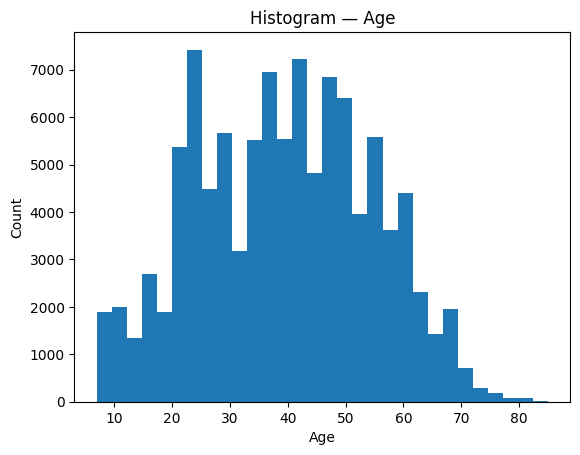

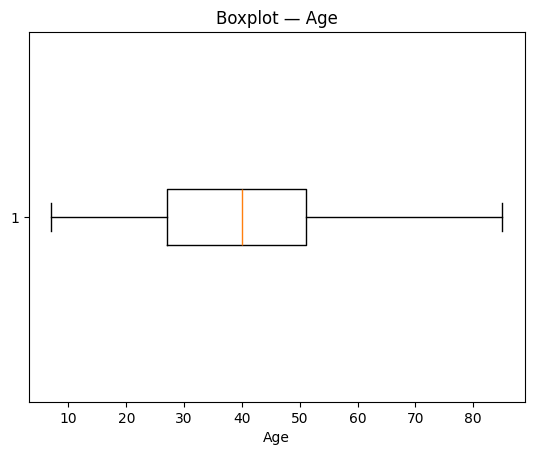

In [ ]:
#Univariate Numerikal
num_cols = ["Arrival Delay in Minutes", "Age", "Flight Distance", "Departure Delay in Minutes"]
# Univariate Numerikal Analysis

# 1. Age Distribution
plt.figure()
plt.hist(df["Age"].dropna(), bins=30)
plt.title("Histogram — Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.boxplot(df["Age"].dropna(), vert=False)
plt.title("Boxplot — Age")
plt.xlabel("Age")
plt.show()


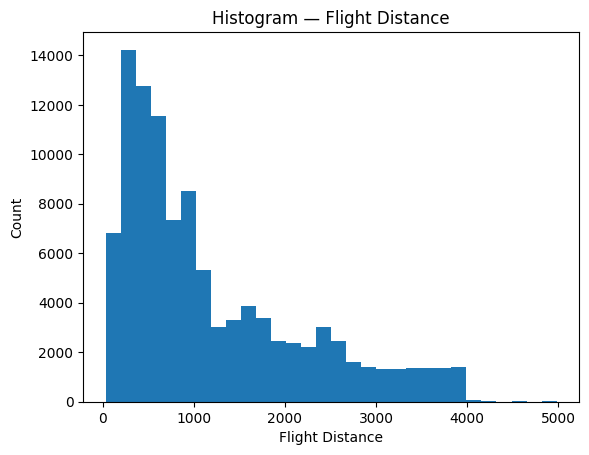

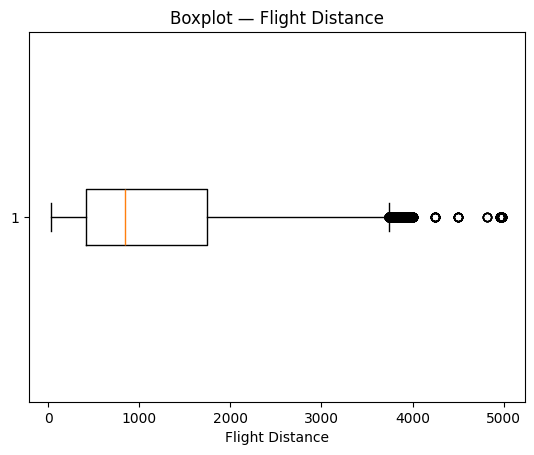

In [ ]:
# 2. Flight Distance Distribution
plt.figure()
plt.hist(df["Flight Distance"].dropna(), bins=30)
plt.title("Histogram — Flight Distance")
plt.xlabel("Flight Distance")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.boxplot(df["Flight Distance"].dropna(), vert=False)
plt.title("Boxplot — Flight Distance")
plt.xlabel("Flight Distance")
plt.show()


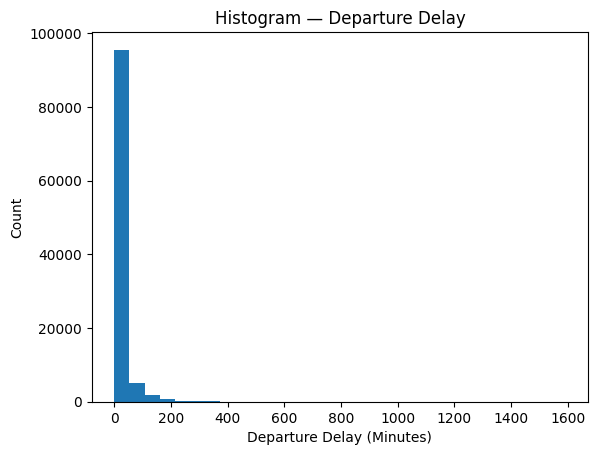

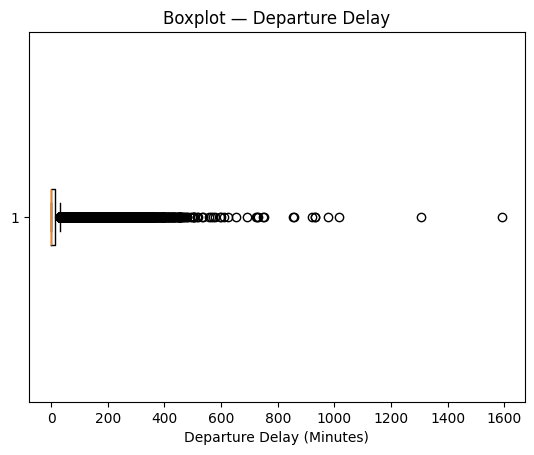

In [ ]:
# 3. Departure Delay Distribution
plt.figure()
plt.hist(df["Departure Delay in Minutes"].dropna(), bins=30)
plt.title("Histogram — Departure Delay")
plt.xlabel("Departure Delay (Minutes)")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.boxplot(df["Departure Delay in Minutes"].dropna(), vert=False)
plt.title("Boxplot — Departure Delay")
plt.xlabel("Departure Delay (Minutes)")
plt.show()


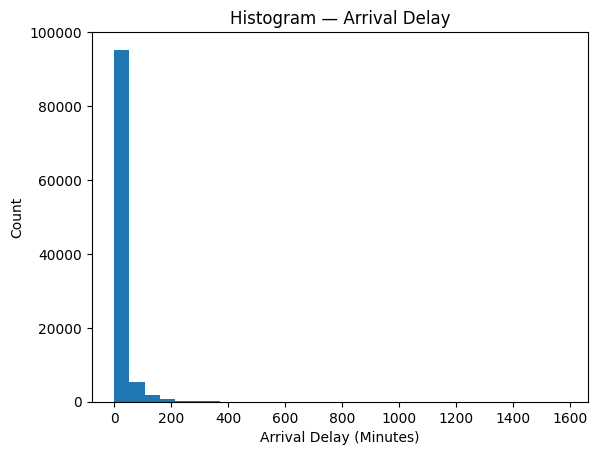

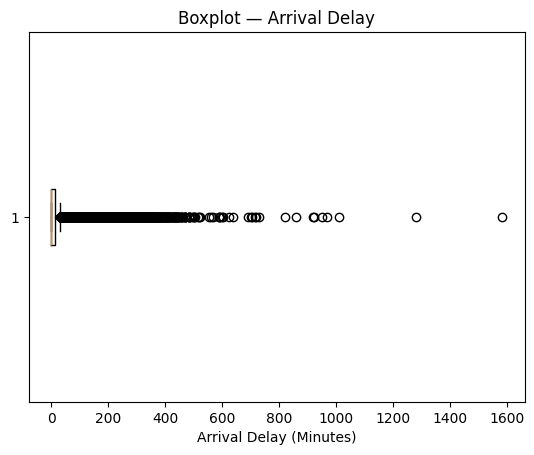

In [ ]:
# 4. Arrival Delay Distribution
plt.figure()
plt.hist(df["Arrival Delay in Minutes"].dropna(), bins=30)
plt.title("Histogram — Arrival Delay")
plt.xlabel("Arrival Delay (Minutes)")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.boxplot(df["Arrival Delay in Minutes"].dropna(), vert=False)
plt.title("Boxplot — Arrival Delay")
plt.xlabel("Arrival Delay (Minutes)")
plt.show()

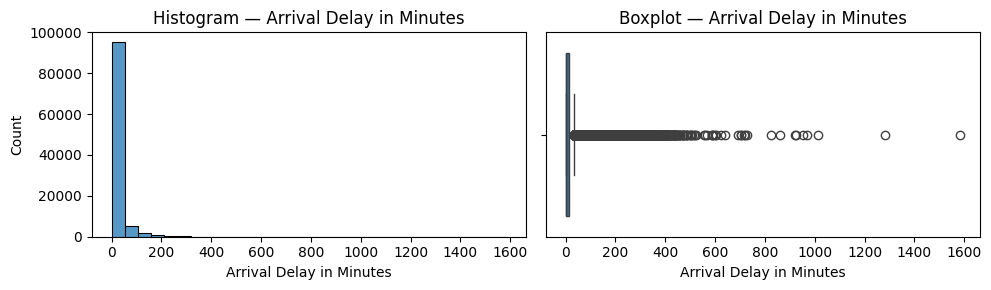

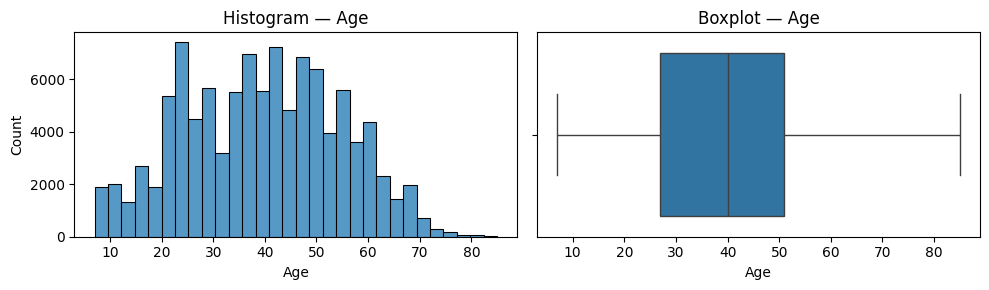

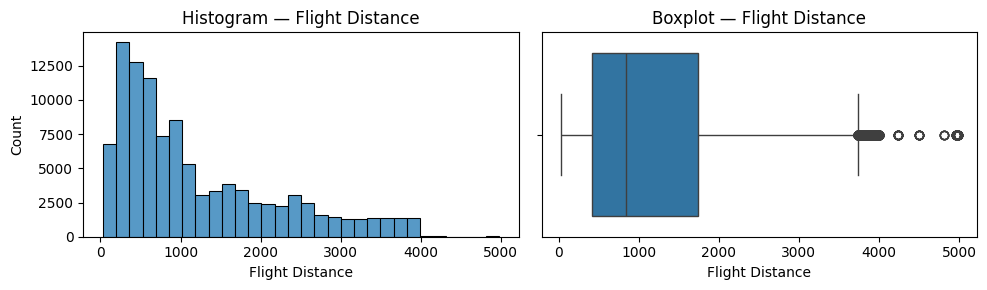

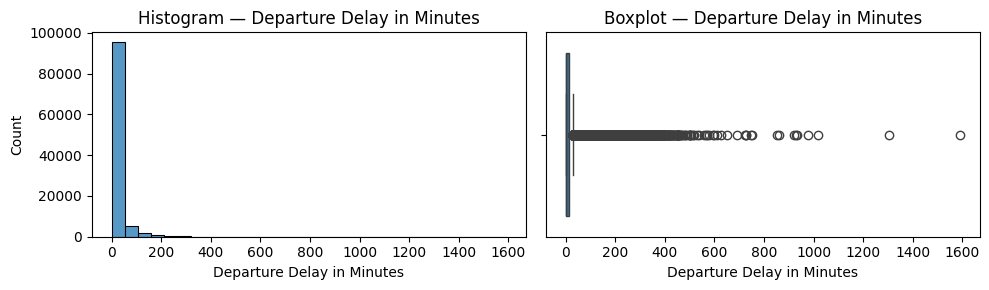

In [ ]:
#parch
num_cols = ["Arrival Delay in Minutes", "Age", "Flight Distance", "Departure Delay in Minutes"]

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    sns.histplot(df[col].dropna(), bins=30, ax=axes[0])
    axes[0].set_title(f"Histogram — {col}")

    sns.boxplot(x=df[col].dropna(), ax=axes[1])
    axes[1].set_title(f"Boxplot — {col}")

    plt.tight_layout()
    plt.show()

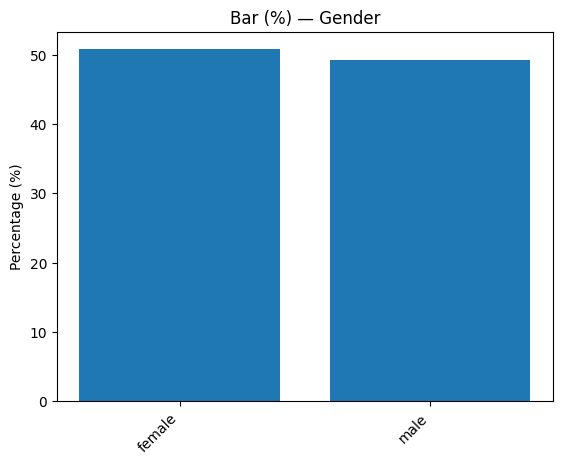

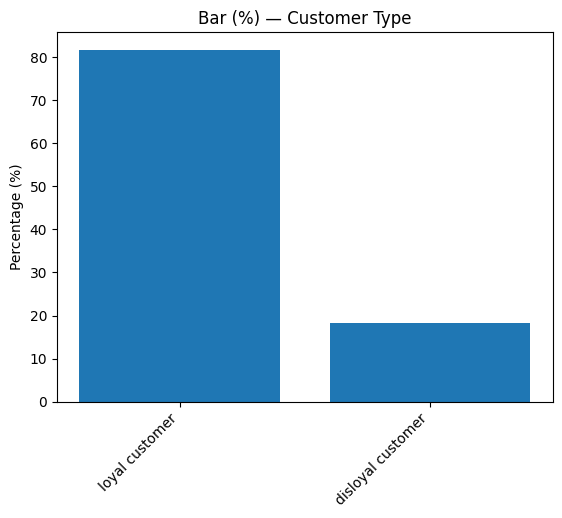

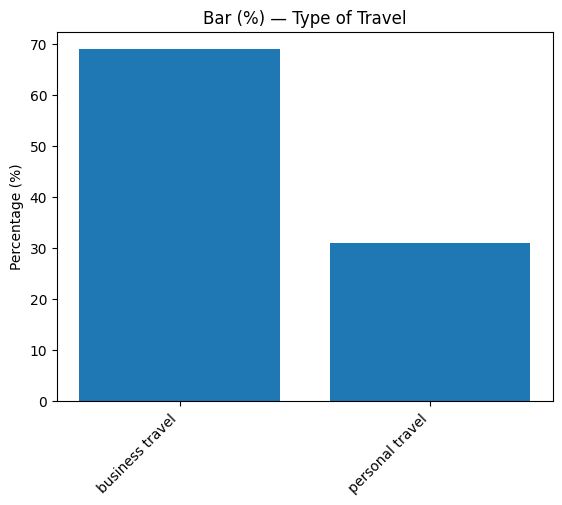

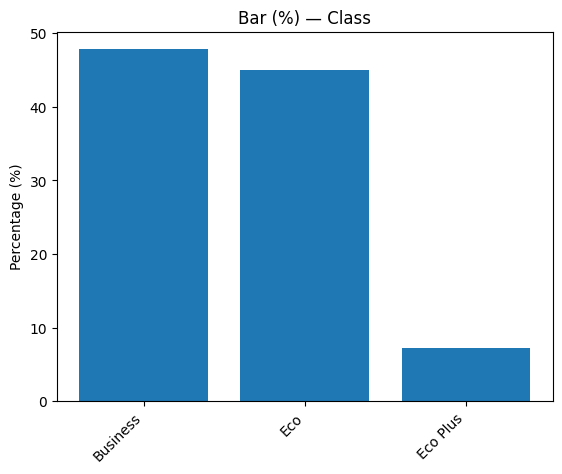

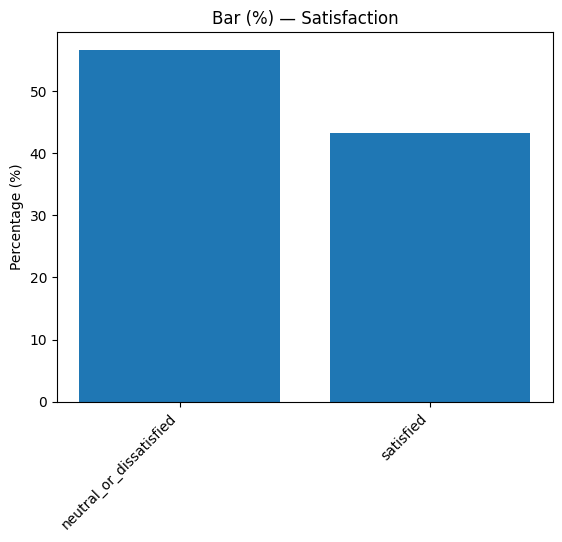

In [ ]:
#Univariate Kategorikal
def bar_pct(series, title):
    vc = series.value_counts(dropna=False)
    pct = (vc / len(series) * 100).round(2)
    plt.figure()
    plt.bar(vc.index.astype(str), pct.values)
    plt.title(title)
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=45, ha="right")
    plt.show()

bar_pct(df["Gender"], "Bar (%) — Gender")
bar_pct(df["Customer Type"], "Bar (%) — Customer Type")
bar_pct(df["Type of Travel"], "Bar (%) — Type of Travel")
bar_pct(df["Class"], "Bar (%) — Class")
bar_pct(df["satisfaction"], "Bar (%) — Satisfaction")

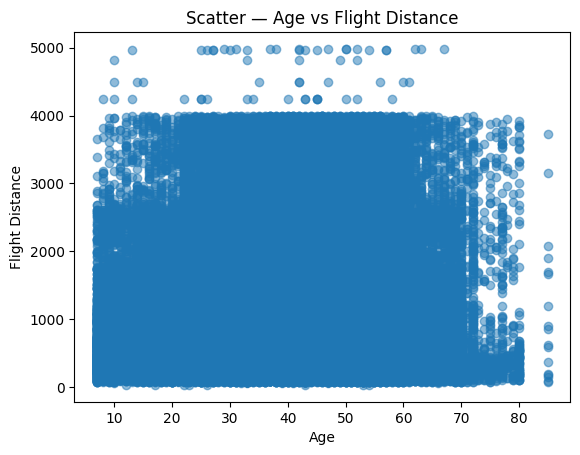

In [ ]:
#Bivariate Numerikal vs Numerikal
plt.figure()
plt.scatter(df["Age"], df["Flight Distance"], alpha=0.5)
plt.title("Scatter — Age vs Flight Distance")
plt.xlabel("Age")
plt.ylabel("Flight Distance")
plt.show()

/tmp/ipython-input-3465682260.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=sorted(df["Customer Type"].unique()))


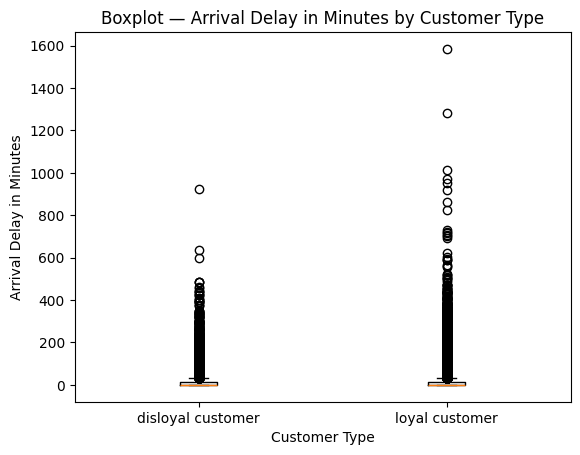

In [ ]:
#bivariate numerikal vs kategorikal
groups = [df.loc[df["Customer Type"] == c, "Arrival Delay in Minutes"].dropna() for c in sorted(df["Customer Type"].unique())]

plt.figure()
plt.boxplot(groups, labels=sorted(df["Customer Type"].unique()))
plt.title("Boxplot — Arrival Delay in Minutes by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Arrival Delay in Minutes")
plt.show()

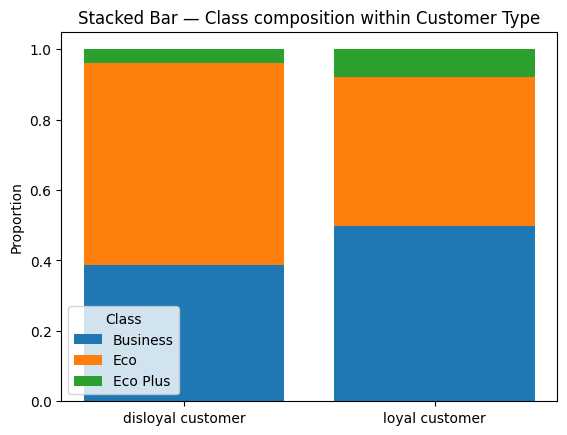

In [ ]:
#bivariate kategorikal vs kategorikal
ct = pd.crosstab(df["Customer Type"], df["Class"], normalize="index")
plt.figure()
bottom = np.zeros(len(ct.index))
for col in ct.columns:
    plt.bar(ct.index.astype(str), ct[col].values, bottom=bottom, label=str(col))
    bottom += ct[col].values
plt.title("Stacked Bar — Class composition within Customer Type")
plt.ylabel("Proportion")
plt.legend(title="Class")
plt.show()

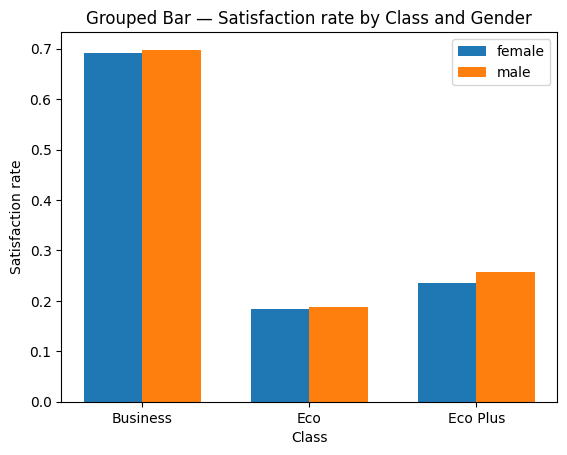

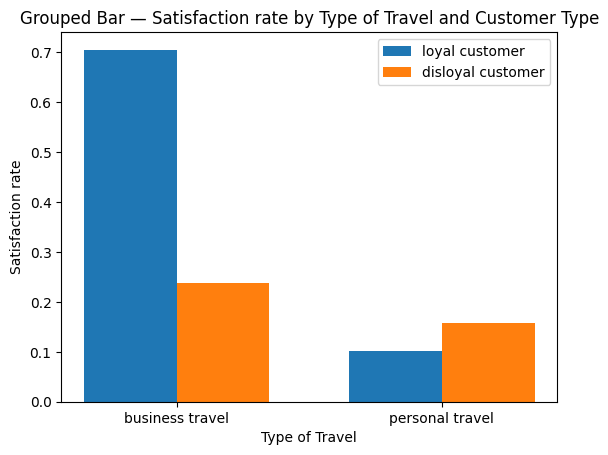

In [ ]:
#multivariate
df["satisfaction_binary"] = df["satisfaction"].apply(lambda x: 1 if x == "satisfied" else 0)
# 1. Satisfaction rate by Class and Gender
rate = df.groupby(["Class", "Gender"])["satisfaction_binary"].mean().unstack()
x = np.arange(len(rate.index))
width = 0.35

plt.figure()
plt.bar(x - width/2, rate["female"], width, label="female")
plt.bar(x + width/2, rate["male"], width, label="male")
plt.xticks(x, rate.index.astype(str))
plt.title("Grouped Bar — Satisfaction rate by Class and Gender")
plt.xlabel("Class")
plt.ylabel("Satisfaction rate")
plt.legend()
plt.show()

# 2. Satisfaction rate by Type of Travel and Customer Type
rate = df.groupby(["Type of Travel", "Customer Type"])["satisfaction_binary"].mean().unstack()
x = np.arange(len(rate.index))
width = 0.35

plt.figure()
plt.bar(x - width/2, rate["loyal customer"], width, label="loyal customer")
plt.bar(x + width/2, rate["disloyal customer"], width, label="disloyal customer")
plt.xticks(x, rate.index.astype(str))
plt.title("Grouped Bar — Satisfaction rate by Type of Travel and Customer Type")
plt.xlabel("Type of Travel")
plt.ylabel("Satisfaction rate")
plt.legend()
plt.show()

Insight 1: Distribusi Usia Penumpang
Temuan: Distribusi usia penumpang cenderung normal dengan rentang 7–85 tahun dan puncak sekitar usia 40 tahun.

Implikasi: Mayoritas penumpang berada dalam kelompok usia produktif (27–51 tahun). Hal ini dapat mempengaruhi preferensi layanan seperti hiburan, kenyamanan kursi, dan kemudahan booking online.

Insight 2: Jarak Penerbangan Cenderung Pendek hingga Menengah
Temuan: Sebagian besar penerbangan berjarak di bawah 2000 mil, dengan puncak distribusi sekitar 400–800 mil.

Implikasi: Maskapai mungkin lebih banyak melayani rute domestik atau regional. Layanan seperti wifi dan makanan/minuman mungkin lebih kritis untuk penerbangan jarak menengah.

Insight 3: Tingkat Kepuasan Tidak Seimbang
Temuan: Proporsi penumpang neutral or dissatisfied (56,6%) lebih tinggi daripada satisfied (43,4%).

Implikasi: Ada ruang besar untuk perbaikan layanan secara menyeluruh. Analisis lebih lanjut diperlukan untuk mengidentifikasi faktor dominan penyebab ketidakpuasan.

Insight 4: Loyalitas Pelanggan Tidak Menjamin Kepuasan
Temuan: Meski 81,7% penumpang adalah Loyal Customer, tingkat ketidakpuasan tetap tinggi.

Implikasi: Loyalitas tidak selalu berkorelasi dengan kepuasan. Kemungkinan ada isu layanan yang membuat pelanggan setia tetap merasa tidak puas.

Insight 5: Keterlambatan Kedatangan Memiliki Missing Values
Temuan: Terdapat 310 missing values (0,3%) pada kolom Arrival Delay in Minutes.

Implikasi: Data ini penting karena keterlambatan dapat mempengaruhi kepuasan. Perlu imputasi yang tepat (misalnya berdasarkan Departure Delay atau median per grup) agar tidak mengganggu analisis.

Insight 6: Layanan dengan Skor Tertinggi dan Terendah
Temuan:

Skor tertinggi: Baggage handling (3,63) dan Inflight service (3,64).

Skor terendah: Inflight wifi service (2,73) dan Ease of Online booking (2,76).

Implikasi: Layanan digital (wifi dan booking online) menjadi titik lemah utama. Perbaikan di area ini dapat meningkatkan kepuasan secara signifikan.

# EDA-Driven Action (Pre-processing 2)

In [ ]:
#EDA 2
#KEPUTUSAN 1: Handling Missing Values pada Arrival Delay

#Temuan:
#- Kolom "Arrival Delay in Minutes" memiliki 310 missing values (0.3%).
#- Missing value hanya terjadi pada kolom ini, tidak tersebar di kolom lain.
#- Arrival delay sangat berkorelasi dengan departure delay.

#Keputusan:
#- Imputasi missing values menggunakan MEDIAN per grup berdasarkan "Class".
#- Tidak menggunakan mean karena distribusi delay sangat right-skewed (outlier besar hingga 1584 menit).

#Alasan:
#- Median lebih robust terhadap outlier.
#- Grouping by Class membuat imputasi lebih akurat karena pola delay berbeda tiap kelas.
#- Menghindari bias dan mempertahankan distribusi alami data.

#Implementasi:
df["Arrival Delay in Minutes"] = df.groupby("Class")["Arrival Delay in Minutes"]\
                                   .transform(lambda x: x.fillna(x.median()))

#Verifikasi
print("[INFO] Missing values setelah imputasi:", df["Arrival Delay in Minutes"].isna().sum())
print("-" * 70)



#KEPUTUSAN 2: Transformasi Log pada Flight Distance

#Temuan:
#- Distribusi "Flight Distance" sangat right-skewed (banyak di 400–800 mil, ekor panjang hingga 4983 mil).
#- Skewness dapat mengganggu performa model ML berbasis jarak/linear.

#Keputusan:
#- Membuat fitur baru "Flight Distance Log" dengan transformasi logaritmik (np.log1p).
#- Fitur asli tetap dipertahankan untuk fleksibilitas eksplorasi.

#Alasan:
#- Transformasi log menormalkan distribusi, mengurangi efek outlier.
#- Meningkatkan performa model regresi dan clustering.
#- log1p menghindari error pada nilai 0 (tidak ada jarak 0 di dataset, tapi aman digunakan).

#Implementasi:
df["Flight Distance Log"] = np.log1p(df["Flight Distance"])

#Cek hasil transformasi
print("[INFO] Skewness sebelum:", df["Flight Distance"].skew())
print("[INFO] Skewness setelah log:", df["Flight Distance Log"].skew())
print("-" * 70)



#KEPUTUSAN 3: Binary Encoding pada Target Satisfaction
#Temuan:
#- Kolom target "satisfaction" memiliki 2 kategori:
#   - "satisfied" (43.4%)
#   - "neutral or dissatisfied" (56.6%)
#- Model ML tidak bisa memproses data kategorikal secara langsung.

#Keputusan:
#- Membuat kolom biner "satisfaction_binary" dengan mapping:
#   1 = satisfied, 0 = neutral or dissatisfied.

#Alasan:
#- Binary encoding adalah representasi paling sederhana dan efektif untuk klasifikasi biner.
#- Mempertahankan makna ordinal (kepuasan vs tidak puas).
#- Kompatibel dengan semua algoritma ML (logistic regression, tree-based, neural network).

#Implementasi:
df["satisfaction_binary"] = df["satisfaction"].map({
    "satisfied": 1,
    "neutral_or_dissatisfied": 0
})

#Validasi
print("[INFO] Distribusi target biner:")
print(df["satisfaction_binary"].value_counts(normalize=True).round(3))
print("-" * 70)



#KEPUTUSAN 4 (Bonus): Feature Engineering dari Delay

#Temuan:
#- 75% penerbangan tidak mengalami delay (median = 0, Q3 = 12 menit).
#- Namun ada outlier ekstrem hingga 1592 menit (~26 jam).
#- Delay ekstrem ini sangat mungkin mempengaruhi kepuasan secara drastis.

#Keputusan:
#- Membuat fitur biner "Has Delay" (1 jika delay > 0, else 0).
#- Membuat fitur "Delay Severity" dengan kategorisasi:
#    0: No delay, 1: Minor (1–30 min), 2: Moderate (31–60 min), 3: Severe (>60 min).

#Alasan:
#- Model lebih mudah mempelajari pola "apakah delay terjadi" daripada nilai delay mentah.
#- Outlier ekstrem tidak perlu dihapus, cukup dikategorikan.
#- Memberikan interpretasi yang lebih baik untuk rekomendasi bisnis.
#
#Implementasi:
df["Has Departure Delay"] = (df["Departure Delay in Minutes"] > 0).astype(int)
df["Has Arrival Delay"] = (df["Arrival Delay in Minutes"] > 0).astype(int)

#Binning severity
bins = [-1, 0, 30, 60, float("inf")]
labels = ["No Delay", "Minor", "Moderate", "Severe"]
df["Departure Delay Severity"] = pd.cut(df["Departure Delay in Minutes"], bins=bins, labels=labels)
df["Arrival Delay Severity"] = pd.cut(df["Arrival Delay in Minutes"], bins=bins, labels=labels)

print("[INFO] Feature engineering delay selesai.")
print(df[["Has Departure Delay", "Departure Delay Severity"]].head())
print("-" * 70)



#KEPUTUSAN 5 (Bonus): Menghapus Kolom Redundant

#Temuan:
#- Kolom "Unnamed: 0" dan "id" bersifat index unik, tidak memiliki nilai prediktif.
#- Kolom ini hanya menambah dimensi dan berisiko overfitting.

#Keputusan:
#- Drop kedua kolom tersebut.

#Alasan:
#- Reduksi dimensi tanpa kehilangan informasi.
#- Mencegah model mempelajari pola palsu dari ID.

# Implementasi:
df = df.drop(columns=["Unnamed: 0", "id"], errors="ignore")
print("[INFO] Kolom redundant telah dihapus.")
print("Shape setelah drop:", df.shape)
print("-" * 70)


[INFO] Missing values setelah imputasi: 0
----------------------------------------------------------------------
[INFO] Skewness sebelum: 1.1094656676620138
[INFO] Skewness setelah log: -0.2039473926515501
----------------------------------------------------------------------
[INFO] Distribusi target biner:
satisfaction_binary
0    0.567
1    0.433
Name: proportion, dtype: float64
----------------------------------------------------------------------
[INFO] Feature engineering delay selesai.
   Has Departure Delay Departure Delay Severity
0                    1                    Minor
1                    1                    Minor
2                    0                 No Delay
3                    1                    Minor
4                    0                 No Delay
----------------------------------------------------------------------
[INFO] Kolom redundant telah dihapus.
Shape setelah drop: (103904, 29)
----------------------------------------------------------------------


Kesimpulan
Berdasarkan eksplorasi data yang dilakukan, ditemukan bahwa meskipun mayoritas penumpang adalah pelanggan setia (81.7%) dengan usia produktif, tingkat kepuasan secara keseluruhan masih rendah (56.6% tidak puas), mengindikasikan adanya masalah fundamental pada layanan. Faktor yang paling berpengaruh terhadap kepuasan adalah layanan digital, dengan Inflight wifi service dan Ease of Online booking sebagai area dengan skor terendah yang perlu segera ditingkatkan. Selain itu, keterlambatan yang parah juga berdampak signifikan pada ketidakpuasan penumpang. Dataset telah melalui tahap pra-pemrosesan yang matang, termasuk penanganan missing value yang tepat sasaran, rekayasa fitur baru yang informatif, dan normalisasi distribusi data. Hasilnya, data kini siap digunakan untuk pemodelan machine learning guna memprediksi kepuasan penumpang secara akurat.